# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?

- Linear models can produce any value without bounds which is inappropriate for results like probability. General linear models and logistic models can have limits that make them more applicable to real world problems.

2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.

- They are effective because they punish confident incorrect predictions when evaluating for loss during testing.

3. True or false, and explain: Logistic regression is a linear model.

- True, regression is shown as a coefficient and function which is the definition of a linear model.

4. True or false, and explain: Logistic regression cannot be used for classification.

- False, logistic regression is actually very popular for classification as its output is predicted probabilities.

5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?

- No, it affects the log-odds.

6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.

- False, logistic models are linear and feature engineering is needed to model nonlinear patterns.

7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

- False, OLS is useful when looking at continuous outcomes and logistic regression is more useful when looking at binary or categorical outcomes.


**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

- Being a debtor and being older at enrollment predict higher dropout probability, while being up to date on tuition and holding a scholarship predict lower dropout probability. Being up to date on tuition has by far the strongest effect in the model with a coefficient of -2.56, suggesting it is the most important predictor of staying enrolled.

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

- The gap between the purple and yellow clusters is largest for younger students around ages 18-30, where being current on tuition appears to reduce dropout probability by 50% or more. On average, being up to date on tuition reduces the predicted probability of dropout by about 61% across all students.

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

- It is 76.20%.

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

- Both models produce similar distributions overall, but the linear model generates invalid predictions above 1.0 which logistic regression avoids.

6. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

- Based on the model, the most at-risk students are older debtors who are behind on tuition payments and don't hold a scholarship, suggesting that financial hardship is the primary driver of dropout. Based on this, interventions such as emergency tuition assistance and flexible payment plans for students falling behind on payments would likely have the biggest impact on retention.

7. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

- The hard classifier never predicts the enrolled class at all which has created a reduction in accuracy over previous models as the model fails to predict probabilities for the enrolled class as well.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score


In [21]:
# 2.1

student = pd.read_csv("/content/data.csv", delimiter=";")

cols = [
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Target"
]

student = student[cols]

# Drop missing values
student = student.dropna()

# Create binary dummy variable for dropout
student["Dropout"] = (student["Target"] == "Dropout").astype(int)
student.head()


,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target,Dropout
0,0,1,0,20,0,Dropout,1
1,0,0,0,19,6,Graduate,0
2,0,0,0,19,0,Dropout,1
3,0,1,0,20,6,Graduate,0
4,0,1,0,45,5,Graduate,0


In [22]:
# 2.2

# Set model variables
X_train = student[[
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment"
]]
y_train = student["Dropout"]

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

coefs = pd.Series(log_model.coef_[0], index=X_train.columns)
print(coefs)


Debtor                     0.530625
Tuition fees up to date   -2.556542
Scholarship holder        -1.227442
Age at enrollment          0.049925
dtype: float64


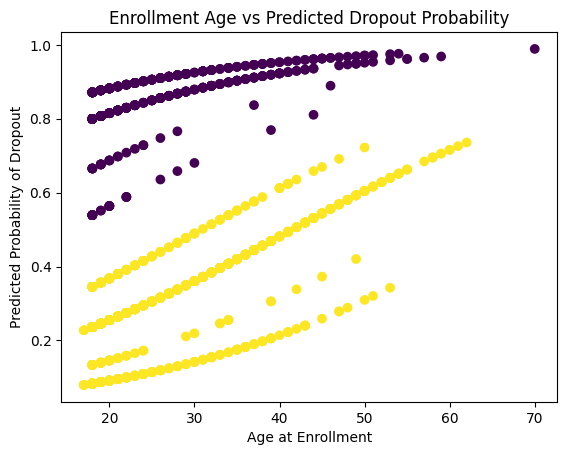

-0.6125849339840048


In [23]:
# 2.3

# Create probabilities of dropout and not dropout and add to df
dropout_probs = log_model.predict_proba(X_train)[:, 1]
student["prob"] = dropout_probs

# Plot relationship
plt.scatter(student["Age at enrollment"], student["prob"],
            c=student["Tuition fees up to date"])
plt.title("Enrollment Age vs Predicted Dropout Probability")
plt.xlabel("Age at Enrollment")
plt.ylabel("Predicted Probability of Dropout")
plt.show()

tuit_means = student.groupby("Tuition fees up to date")["prob"].mean()

tuit_effect = tuit_means[1] - tuit_means[0]
print(tuit_effect)

In [24]:
# 2.4

# Create predictions, confusion matrix and accuracy score
y_preds = log_model.predict(X_train)
conf_matrix = confusion_matrix(y_train, y_preds)
log_acc = accuracy_score(y_train, y_preds)

print(conf_matrix)
print("\nAccuracy:", log_acc)

[[2841  162]
 [ 891  530]]

Accuracy: 0.7619801084990958


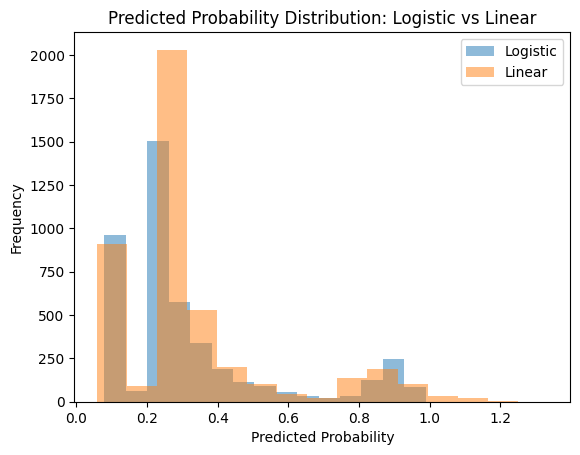


Linear model accuracy: 0.7633363471971067


In [25]:
# 2.5

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

# Get linear predictions
lin_probs = lin_model.predict(X_train)

plt.hist(dropout_probs, alpha=0.5, label="Logistic", bins=15)
plt.hist(lin_probs, alpha=0.5, label="Linear", bins=15)
plt.title("Predicted Probability Distribution: Logistic vs Linear")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.legend()
plt.show()

lin_preds = (lin_probs >= 0.5).astype(int)

lin_acc = accuracy_score(y_train, lin_preds)
print("\nLinear model accuracy:", lin_acc)

In [26]:
# 2.7

X_multi = student[[
    "Debtor",
    "Tuition fees up to date",
    "Curricular units 1st sem (approved)"
]]
y_multi = student["Target"]

# Fit polynomial logistic regression
multi_model = LogisticRegression(multi_class="multinomial", max_iter=1000)
multi_model.fit(X_multi, y_multi)

multi_preds = multi_model.predict(X_multi)
multi_probs = multi_model.predict_proba(X_multi)

conf_matrix_multi = confusion_matrix(y_multi, multi_preds)
multi_acc = accuracy_score(y_multi, multi_preds)

print(conf_matrix_multi)
print("\nAccuracy:", multi_acc)
print(multi_probs)

[[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]

Accuracy: 0.7045660036166366
[[0.68054695 0.21046429 0.10898876]
 [0.69541412 0.1460432  0.15854268]
 [0.95298821 0.04119918 0.00581261]
 ...
 [0.07193813 0.14064437 0.78741751]
 [0.18422683 0.21266883 0.60310434]
 [0.11780804 0.1769832  0.70520876]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

- The drug actually appears to slightly reduce survival probability with a negative coefficient of -0.22. Higher bilirubin also predicts lower survival probability with a coefficient -0.35. Edema has the strongest negative effect of the three variables with a coefficient -0.95.

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

- The drug appears to show slightly higher survivability compared to the control at most levels.

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

- It is 74.36%.

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

- Both models agree broadly on the distribution of predictions, but the linear model produces invalid negative probabilities which the logistic regression avoids.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

- The hard classifier only ever predicts stages 3 and 4, completely ignoring stages 1 and 2 which also checks out with the probabilities.


In [33]:
# 3.1

# Load data
cirrh = pd.read_csv("/content/cirrhosis.csv")
cirrh = cirrh[["Bilirubin", "Edema", "Drug", "Stage", "Status"]]

# Drop rows with missing values
cirrh = cirrh.dropna()

# Code survival
cirrh["Status"] = cirrh["Status"].isin(["C", "CL"]).astype(int)

# Code edema
cirrh["Edema"] = cirrh["Edema"].isin(["Y", "S"]).astype(int)

# Code drug
cirrh["Drug"] = cirrh["Drug"].isin(["D-penicillamine"]).astype(int)

cirrh.head()

,Bilirubin,Edema,Drug,Stage,Status
0,14.5,1,1,4.0,0
1,1.1,0,1,3.0,1
2,1.4,1,1,4.0,0
3,1.8,1,1,4.0,0
4,3.4,0,0,3.0,1


In [34]:
# 3.2

# Define variables
X_cirrh = cirrh[["Bilirubin", "Edema", "Drug"]]
y_cirrh = cirrh["Status"]

# Fit logistic model
cirrh_model = LogisticRegression(max_iter=1000)
cirrh_model.fit(X_cirrh, y_cirrh)
print(pd.Series(cirrh_model.coef_[0], index=X_cirrh.columns))

Bilirubin   -0.353275
Edema       -0.953354
Drug        -0.220258
dtype: float64


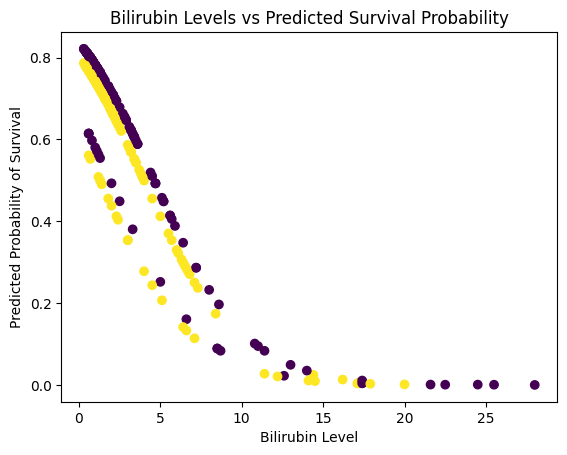

In [36]:
# 3.3

# Generate probabilities for survival
survival_probs = cirrh_model.predict_proba(X_cirrh)[:, 1]

# Plot bilirubin against survival probability
plt.scatter(cirrh["Bilirubin"], survival_probs,
            c=cirrh["Drug"])
plt.title("Bilirubin Levels vs Predicted Survival Probability")
plt.xlabel("Bilirubin Level")
plt.ylabel("Predicted Probability of Survival")
plt.show()


In [37]:
# 3.4

# Generate predictions and confusion matrix
survival_preds = cirrh_model.predict(X_cirrh)
print(confusion_matrix(y_cirrh, survival_preds))
print(accuracy_score(y_cirrh, survival_preds))


[[ 62  63]
 [ 17 170]]
0.7435897435897436


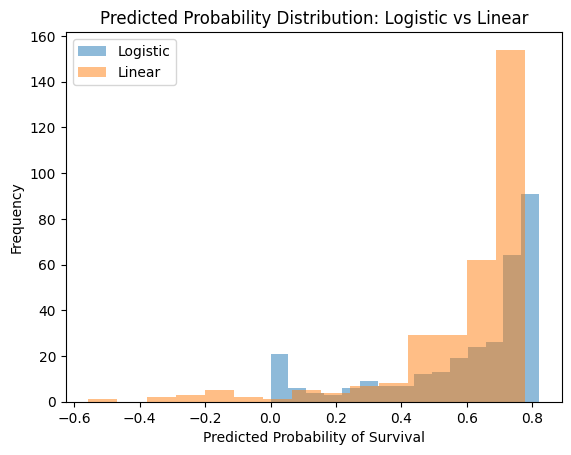


Linear model accuracy: 0.7307692307692307


In [38]:
# 3.5

# Fit linear regression model on same variables
lin_cirrh = LinearRegression()
lin_cirrh.fit(X_cirrh, y_cirrh)

# Create linear predictions
lin_survival_probs = lin_cirrh.predict(X_cirrh)

plt.hist(survival_probs, alpha=0.5, label="Logistic", bins=15)
plt.hist(lin_survival_probs, alpha=0.5, label="Linear", bins=15)
plt.title("Predicted Probability Distribution: Logistic vs Linear")
plt.xlabel("Predicted Probability of Survival")
plt.ylabel("Frequency")
plt.legend()
plt.show()

lin_survival_preds = (lin_survival_probs >= 0.5).astype(int)

lin_survival_acc = accuracy_score(y_cirrh, lin_survival_preds)
print("\nLinear model accuracy:", lin_survival_acc)



In [39]:
# 3.6

# Define variables
X_stage = cirrh[["Bilirubin", "Edema"]]
y_stage = cirrh["Stage"]

# Fit new model
stage_model = LogisticRegression(multi_class="multinomial", max_iter=1000)
stage_model.fit(X_stage, y_stage)

stage_preds = stage_model.predict(X_stage)
stage_probs = stage_model.predict_proba(X_stage)

print(confusion_matrix(y_stage, stage_preds))
print(stage_probs)

[[  0   0  16   0]
 [  0   0  61   6]
 [  0   0 101  19]
 [  0   0  73  36]]
[[9.79519278e-06 4.21650489e-02 2.33385239e-01 7.24439917e-01]
 [7.31485799e-02 2.53001897e-01 3.99709538e-01 2.74139985e-01]
 [2.54740386e-02 1.54654679e-01 3.23327235e-01 4.96544047e-01]
 ...
 [5.30348836e-02 2.47767727e-01 4.09291060e-01 2.89906329e-01]
 [4.50394201e-02 2.44544853e-01 4.13075505e-01 2.97340223e-01]
 [3.69397627e-03 1.81860444e-01 4.26022249e-01 3.88423331e-01]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

- $$
\frac{\delta\hat{y}}{\delta x_k} = b_k
$$

- For a one unit increase in x, it corresponds to b unit increase in y.

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?


- $$\frac{\delta p}{\delta x_k} = b_k \cdot p(1-p)$$

- It is when p equal to around 0.5.

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

- A one unit change in x increases the log odds ratio by exactly b